# 04 · Choosing a policy to deploy — with OPE, not guesswork

The payoff: given the logs from the current system, **which recommender should
we ship?** We score several candidate target policies with Doubly Robust OPE
and check that OPE's ranking matches the (normally unknowable) ground truth.

Candidates:
- the exploratory popularity policy (status quo),
- a soft iALS policy (mild personalisation),
- a sharp iALS policy (aggressive personalisation).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

In [2]:
from sklearn.linear_model import LogisticRegression
from src.data.load import load_ratings, temporal_split
from src.recommenders.ials import IALS
from src.ope.estimators import (softmax_policy, simulate_bandit_logs, true_policy_value,
                                 doubly_robust, ips)

df = load_ratings(); sp = temporal_split(df, 0.2, 10)
train = sp.train_matrix(); ials = IALS().fit(train)
pop = np.asarray(train.sum(axis=0)).ravel(); users = np.arange(sp.n_users)
N_CAND = 200; cand = np.argsort(-pop)[:N_CAND]
liked = set(map(tuple, df[df.liked == 1][["user_idx", "item_idx"]].values))
R = np.array([[1.0 if (u, i) in liked else 0.0 for i in cand] for u in users])
ials_scores = ials.score_users(users)[:, cand]; pop_scores = np.tile(pop[cand], (len(users), 1))

# logging policy (the system that produced the logs)
pi0 = softmax_policy(pop_scores, temperature=pop[cand].std() * 3, epsilon=0.5)

candidates = {
    "Popularity (status quo)": softmax_policy(pop_scores, temperature=pop[cand].std() * 3, epsilon=0.2),
    "iALS soft":  softmax_policy(ials_scores, temperature=1.0, epsilon=0.05),
    "iALS sharp": softmax_policy(ials_scores, temperature=0.3, epsilon=0.05),
}

In [3]:
log = simulate_bandit_logs(pi0, R, seed=0)
u, a, r, ps = log["context"], log["action"], log["reward"], log["pscore"]
rm = LogisticRegression(max_iter=500).fit(
    np.column_stack([ials_scores[u, a], np.log1p(pop[cand][a])]), r)
feats_all = np.column_stack([ials_scores[u].ravel(), np.log1p(np.tile(pop[cand], len(u)))])
q_all = rm.predict_proba(feats_all)[:, 1].reshape(len(u), N_CAND)
q_logged = q_all[np.arange(len(u)), a]

rows = []
for name, pi in candidates.items():
    tps = pi[u, a]
    v_target = np.sum(pi[u] * q_all, axis=1)
    rows.append({
        "policy": name,
        "true_value": true_policy_value(pi, R),
        "DR_estimate": doubly_robust(r, ps, tps, q_logged, v_target),
        "IPS_estimate": ips(r, ps, tps),
    })
board = pd.DataFrame(rows).set_index("policy")
board

,true_value,DR_estimate,IPS_estimate
policy,,,
Popularity (status quo),0.205582,0.210788,0.210601
iALS soft,0.243467,0.247755,0.247097
iALS sharp,0.413456,0.420500,0.419674


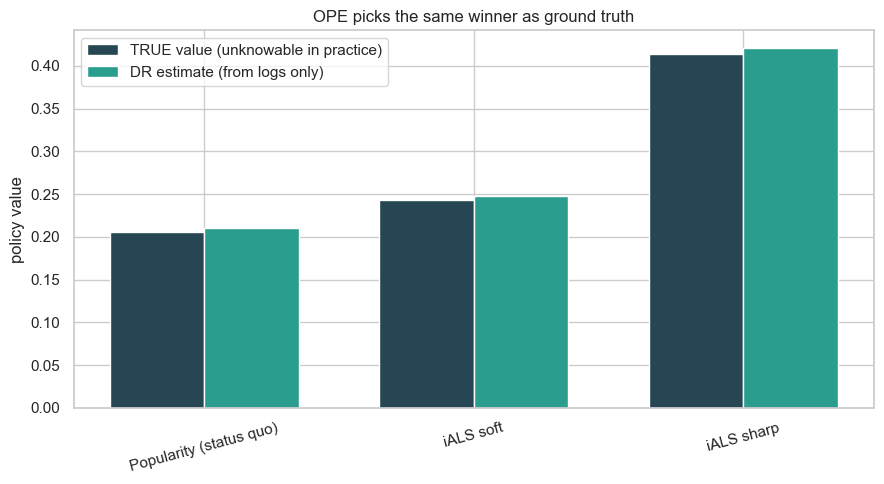

ground-truth best policy : iALS sharp
OPE (DR) best policy     : iALS sharp
OPE selected the correct policy: True


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(board)); w = 0.35
ax.bar(x - w/2, board["true_value"], w, label="TRUE value (unknowable in practice)", color="#264653")
ax.bar(x + w/2, board["DR_estimate"], w, label="DR estimate (from logs only)", color="#2a9d8f")
ax.set_xticks(x); ax.set_xticklabels(board.index, rotation=15); ax.set_ylabel("policy value")
ax.set_title("OPE picks the same winner as ground truth"); ax.legend()
plt.tight_layout(); plt.savefig(FIG / "04_policy_choice.png", dpi=120, bbox_inches="tight"); plt.show()
winner_true = board.true_value.idxmax(); winner_dr = board.DR_estimate.idxmax()
print(f"ground-truth best policy : {winner_true}")
print(f"OPE (DR) best policy     : {winner_dr}")
print("OPE selected the correct policy:", winner_true == winner_dr)

## Takeaways

- **DR-OPE selects the same winning policy as the ground truth** — the sharp
  iALS recommender — using only logged data from the status-quo system.
- The estimated values track the true values closely across all three
  candidates, so OPE is trustworthy for *ranking* policies here, not just
  scoring one.
- **Business impact:** this is the difference between shipping the right
  recommender immediately and burning weeks of A/B-test traffic (and exposing
  users to worse candidates) to learn the same thing. OPE turns the existing
  logs into a decision.

*Caveats:* OPE is reliable only where the logging policy explores the actions
the target policy favours (adequate overlap / ESS). A near-deterministic
logging policy would break IPS/DR, and any shortlisted policy should still get
a final confirmatory A/B test before full rollout.